# Sentiment Analysis

**Sentiment analysis** is a natural language processing (NLP) technique used to identify and extract subjective information from text.

## Download Dataset

Twitter US Airline Sentiment dataset from [Kaggle](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment/data). Contains ~14,000 tweets directed at major US airlines, each labeled as positive, neutral, or negative. Ideal for learning preprocessing since tweets are messy by nature, containing hashtags, @mentions, slang, and irregular punctuation.

In [ ]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")

print("Path to dataset files:", path)

df = pd.read_csv(path + "/Tweets.csv")

df.head()

Using Colab cache for faster access to the 'twitter-airline-sentiment' dataset.
Path to dataset files: /kaggle/input/twitter-airline-sentiment


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Import Libraries

In [ ]:
!pip install gensim contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

RANDOM_STATE = 42

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Exploratory Data Analysis

### Dataset Shape and Column Overview

In [ ]:
print("Shape:", df.shape)
print()
print("Columns:", df.columns)
print()
print("Null counts:")
print(df[['text', 'airline_sentiment']].isnull().sum())

Shape: (14640, 15)

Columns: Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

Null counts:
text                 0
airline_sentiment    0
dtype: int64


### Sentiment Class Distribution

/tmp/ipython-input-3315838437.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,


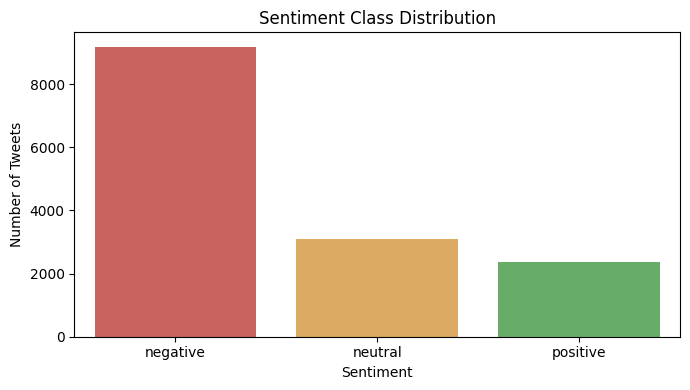

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [ ]:
sentiment_counts = df['airline_sentiment'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            palette=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

print(sentiment_counts)

### A Sample of Raw Tweets
Notice the noise in the raw tweets: @mentions, URLs, mixed capitalization, and messy grammar.

In [ ]:
# Narrow to just the columns we care about
df = df[['text', 'airline', 'airline_sentiment']].dropna()

for sentiment in ['positive', 'neutral', 'negative']:
    print(f"--- {sentiment.upper()} ---")
    samples = df[df['airline_sentiment'] == sentiment]['text'].sample(2, random_state=RANDOM_STATE)
    for tweet in samples:
        print(f"  {tweet}")
    print()

--- POSITIVE ---
  @SouthwestAir thanks for your excellent response time and assistance! All set :)
  @JetBlue thanks. I appreciate your prompt response.

--- NEUTRAL ---
  @united we finally just arrive to Bogota, good but long flight!!
  @AmericanAir got a callback at 1 am, took care of it. thanks.

--- NEGATIVE ---
  @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi
  @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.



## Text Preprocessing

Before we can extract meaningful features, we need to clean and normalize the text.

### Step 1: Text Cleaning

The first step is removing content that doesn't carry useful semantic meaning for our task. For tweet data specifically, this would include URLS, @mentions, hashtags, etc.

In [ ]:
def clean_text(text):
    text = contractions.fix(text)                        # Expand contractions
    text = text.lower()                                  # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)           # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#', '', text)                        # Remove # symbol (keep word)
    text = re.sub(r'[^\w\s]', '', text)                  # Remove punctuation
    text = re.sub(r'\b\d+\b', '', text)                  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()             # Remove extra whitespace
    return text

df['cleaned'] = df['text'].apply(clean_text)

# Compare before and after for a few examples
for i in range(3):
    print(f"BEFORE: {df['text'].iloc[i]}")
    print(f"AFTER:  {df['cleaned'].iloc[i]}")
    print()

BEFORE: @VirginAmerica What @dhepburn said.
AFTER:  what said

BEFORE: @VirginAmerica plus you've added commercials to the experience... tacky.
AFTER:  plus you have added commercials to the experience tacky

BEFORE: @VirginAmerica I didn't today... Must mean I need to take another trip!
AFTER:  i did not today must mean i need to take another trip



**Note:** Removing @mentions discards airline identity from the text. With this dataset, that's acceptable since the `airline` column gives us that information directly, but in a real-world scenario the mention may be your only signal for which entity is being discussed.

### Step 2: Tokenization

**Tokenization** is the process of splitting a string of text into a list of individual units called **tokens**, which are typically words.

In [ ]:
df['tokens'] = df['cleaned'].apply(word_tokenize)

# Show a few examples
for i in range(3):
    print(f"Cleaned: {df['cleaned'].iloc[i]}")
    print(f"Tokens:  {df['tokens'].iloc[i]}")
    print()

Cleaned: what said
Tokens:  ['what', 'said']

Cleaned: plus you have added commercials to the experience tacky
Tokens:  ['plus', 'you', 'have', 'added', 'commercials', 'to', 'the', 'experience', 'tacky']

Cleaned: i did not today must mean i need to take another trip
Tokens:  ['i', 'did', 'not', 'today', 'must', 'mean', 'i', 'need', 'to', 'take', 'another', 'trip']



### Step 3: Stop Word Removal

**Stop words** are extremely common words that appear in almost every document and carry very little meaning on their own,e.g., *the*, *is*, *at*, *which*, and *on*.

In [ ]:
stop_words = set(stopwords.words('english'))

print("Example stop words:", list(stop_words)[:15])

Example stop words: ['hasn', 'the', 'as', 'that', 'yours', 'aren', 'we', "he's", 'ma', "we'll", 's', 'by', 'for', "he'll", 'once']


In [ ]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

# Compare before and after
for i in range(3):
    print(f"With stop words:    {df['tokens'].iloc[i]}")
    print(f"Without stop words: {df['tokens_no_sw'].iloc[i]}")
    print()

With stop words:    ['what', 'said']
Without stop words: ['said']

With stop words:    ['plus', 'you', 'have', 'added', 'commercials', 'to', 'the', 'experience', 'tacky']
Without stop words: ['plus', 'added', 'commercials', 'experience', 'tacky']

With stop words:    ['i', 'did', 'not', 'today', 'must', 'mean', 'i', 'need', 'to', 'take', 'another', 'trip']
Without stop words: ['today', 'must', 'mean', 'need', 'take', 'another', 'trip']



### Step 4: Stemming

**Stemming** reduces words to their root form by chopping off suffixes using a rule-based algorithm.

In [ ]:
stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

df['tokens_stemmed'] = df['tokens_no_sw'].apply(stem_tokens)

# Show a few examples
for i in range(3):
    print(f"Before stemming: {df['tokens_no_sw'].iloc[i]}")
    print(f"After stemming:  {df['tokens_stemmed'].iloc[i]}")
    print()

Before stemming: ['said']
After stemming:  ['said']

Before stemming: ['plus', 'added', 'commercials', 'experience', 'tacky']
After stemming:  ['plu', 'ad', 'commerci', 'experi', 'tacki']

Before stemming: ['today', 'must', 'mean', 'need', 'take', 'another', 'trip']
After stemming:  ['today', 'must', 'mean', 'need', 'take', 'anoth', 'trip']



### Step 5: Lemmatization

**Lemmatization** is similar to stemming, but instead of crudely chopping off suffixes, it uses a vocabulary and grammar rules to return the proper dictionary form of a word, the **lemma**. For example, *better* → *good*, *ran* → *run*, *geese* → *goose*.

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens_lemmatized'] = df['tokens_no_sw'].apply(lemmatize_tokens)

# Compare stemming vs lemmatization
for i in range(3):
    print(f"Original:      {df['tokens_no_sw'].iloc[i]}")
    print(f"Stemmed:       {df['tokens_stemmed'].iloc[i]}")
    print(f"Lemmatized:    {df['tokens_lemmatized'].iloc[i]}")
    print()

Original:      ['said']
Stemmed:       ['said']
Lemmatized:    ['said']

Original:      ['plus', 'added', 'commercials', 'experience', 'tacky']
Stemmed:       ['plu', 'ad', 'commerci', 'experi', 'tacki']
Lemmatized:    ['plus', 'added', 'commercial', 'experience', 'tacky']

Original:      ['today', 'must', 'mean', 'need', 'take', 'another', 'trip']
Stemmed:       ['today', 'must', 'mean', 'need', 'take', 'anoth', 'trip']
Lemmatized:    ['today', 'must', 'mean', 'need', 'take', 'another', 'trip']



### Full Preprocessing Pipeline

Let's package everything into a single pipeline function.

In [ ]:
def preprocess(text):
  # TODO: Write a function to preprocess the text
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

df['processed'] = df['text'].apply(preprocess)

# Final comparison
for i in range(3):
    print(f"Raw:       {df['text'].iloc[i]}")
    print(f"Processed: {df['processed'].iloc[i]}")
    print()

Raw:       @VirginAmerica What @dhepburn said.
Processed: said

Raw:       @VirginAmerica plus you've added commercials to the experience... tacky.
Processed: plus added commercial experience tacky

Raw:       @VirginAmerica I didn't today... Must mean I need to take another trip!
Processed: today must mean need take another trip



## Feature Extraction

**Feature extraction** is the process of converting preprocessed text into numerical representations that a model can learn from.

### Bag of Words (BoW)

The **Bag of Words** model represents each document as a vector of word counts.

In [ ]:
bow_vectorizer = CountVectorizer(max_features=1000)
X_bow = bow_vectorizer.fit_transform(df['processed'])

print("BoW Matrix Shape:", X_bow.shape)
print("Each tweet is represented as a vector of", X_bow.shape[1], "word counts.")
print()

# Show the vocabulary for a few common words
vocab = bow_vectorizer.get_feature_names_out()
print("Sample vocabulary:", vocab[:20].tolist())

BoW Matrix Shape: (14640, 1000)
Each tweet is represented as a vector of 1000 word counts.

Sample vocabulary: ['1hr', '1k', '1st', '2hrs', '2nd', '3rd', 'aa', 'able', 'absolute', 'absolutely', 'acceptable', 'access', 'account', 'actual', 'actually', 'add', 'added', 'address', 'advisory', 'afternoon']


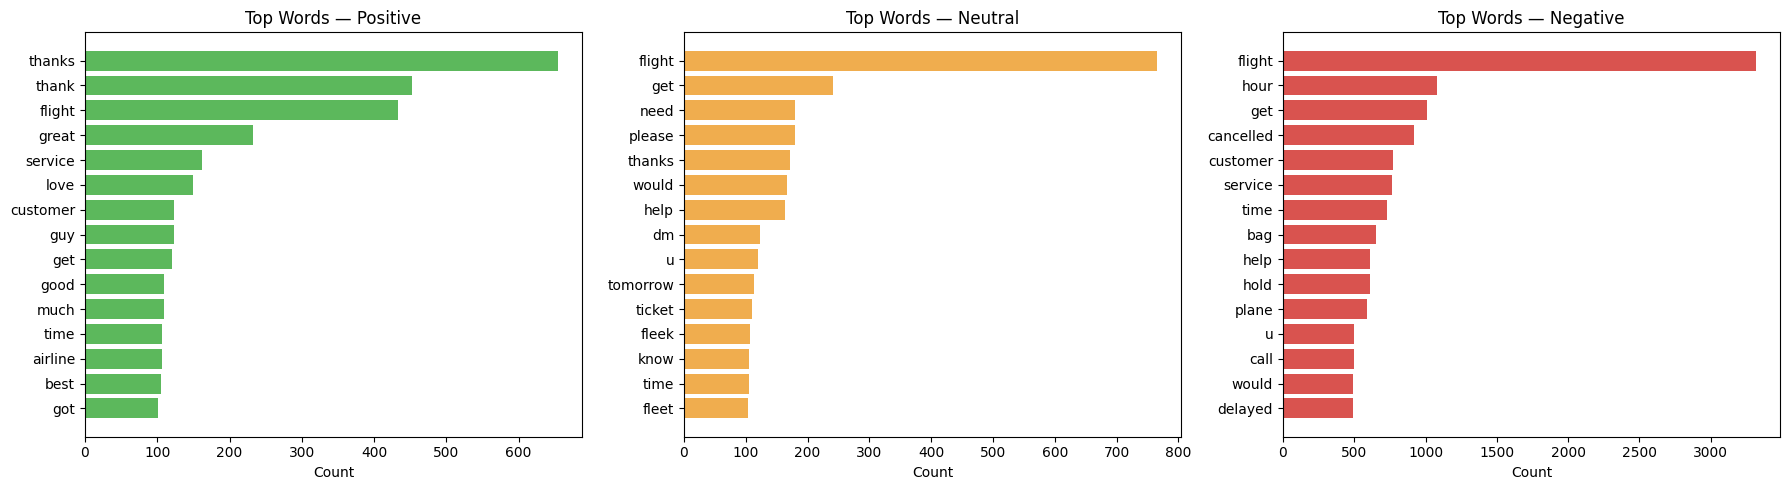

In [ ]:
# Visualize the most common words in each sentiment class
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'positive': '#5cb85c', 'neutral': '#f0ad4e', 'negative': '#d9534f'}

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    subset = df[df['airline_sentiment'] == sentiment]['processed']
    all_words = ' '.join(subset).split()
    word_freq = Counter(all_words).most_common(15)
    words, counts = zip(*word_freq)

    ax.barh(words[::-1], counts[::-1], color=colors[sentiment])
    ax.set_title(f'Top Words — {sentiment.capitalize()}')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

### TF-IDF (Term Frequency–Inverse Document Frequency)

**TF-IDF** improves on raw word counts by downweighting words that appear very frequently across all documents (and are therefore less informative) and upweighting words that are rare but appear often in a particular document.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed'])

print("TF-IDF Matrix Shape:", X_tfidf.shape)
print()

# Compare BoW vs TF-IDF scores for the same tweet
sample_idx = 0
sample_tweet = df['processed'].iloc[sample_idx]
print(f"Sample tweet: '{sample_tweet}'")
print()

bow_scores = zip(bow_vectorizer.get_feature_names_out(), X_bow[sample_idx].toarray()[0])
tfidf_scores = zip(tfidf_vectorizer.get_feature_names_out(), X_tfidf[sample_idx].toarray()[0])

bow_nonzero = [(w, s) for w, s in bow_scores if s > 0]
tfidf_nonzero = [(w, round(s, 4)) for w, s in tfidf_scores if s > 0]

print("BoW (non-zero entries):", bow_nonzero)
print("TF-IDF (non-zero entries):", tfidf_nonzero)

TF-IDF Matrix Shape: (14640, 1000)

Sample tweet: 'said'

BoW (non-zero entries): [('said', np.int64(1))]
TF-IDF (non-zero entries): [('said', np.float64(1.0))]


### Word Embeddings (Word2Vec)

**Word embeddings** represent each word as a dense vector in a continuous vector space, where semantically similar words end up close together.

**Word2Vec** learns these embeddings by training a neural network to predict a word from its neighbors (or vice versa).

In [ ]:
# Word2Vec expects a list of token lists
tokenized_corpus = df['tokens_lemmatized'].tolist()

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,   # Dimensionality of the embedding vectors
    window=5,          # Context window size (words to left and right)
    min_count=2,       # Ignore words that appear fewer than 2 times
    workers=4,
    seed=RANDOM_STATE
)

print("Vocabulary size:", len(w2v_model.wv))
print()
print("Vector for 'delay' (first 10 dimensions):")
print(w2v_model.wv['delay'][:10])

Vocabulary size: 5324

Vector for 'delay' (first 10 dimensions):
[ 0.3881319   0.01656296 -0.33121237 -0.09890653 -0.6287788   0.6091073
  0.4499397   0.31858367 -0.11306471 -0.03721377]


In [ ]:
# Find words most similar to 'delay'
print("Words most similar to 'delay':")
for word, score in w2v_model.wv.most_similar('delay', topn=8):
    print(f"  {word:<20} similarity: {score:.4f}")

Words most similar to 'delay':
  two                  similarity: 0.9982
  another              similarity: 0.9978
  mechanical           similarity: 0.9977
  due                  similarity: 0.9975
  connecting           similarity: 0.9969
  missed               similarity: 0.9960
  departure            similarity: 0.9955
  trying               similarity: 0.9953


In [ ]:
# Create document-level embeddings by averaging word vectors
def get_doc_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([get_doc_embedding(tokens, w2v_model) for tokens in tokenized_corpus])

print("Word2Vec document matrix shape:", X_w2v.shape)
print("Each tweet is now represented as a", X_w2v.shape[1], "-dimensional dense vector.")

Word2Vec document matrix shape: (14640, 100)
Each tweet is now represented as a 100 -dimensional dense vector.


## Modeling

With our features ready, we can now train models to predict sentiment.

### Train/ Test Split
First, we set up a train/test split so we can evaluate each model fairly.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y = df['airline_sentiment']

# TF-IDF splits (used for rule-based, ML, and hybrid)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Word2Vec splits (used for neural network)
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    X_w2v, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train_tfidf.shape[0])
print("Test size: ", X_test_tfidf.shape[0])

Train size: 11712
Test size:  2928


### Handling Class Imbalance

As we saw in the EDA, the dataset is heavily skewed toward negative tweets. Without accounting for this, models tend to over-predict the majority class. We use **SMOTE** (Synthetic Minority Oversampling Technique) to fix this.

See [this](https://colab.research.google.com/drive/1m9ZkDcOALQ1pR_67UZ8vXJNac00OOztM?usp=sharing) data balancing lab from last semester for more on SMOTE!

In [ ]:
!pip install imbalanced-learn -q

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)

X_train_tfidf_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train)
X_train_w2v_bal, _             = smote.fit_resample(X_train_w2v, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", dict(zip(*np.unique(y_train_bal, return_counts=True))))

Before SMOTE: {'negative': 7343, 'neutral': 2479, 'positive': 1890}
After SMOTE:  {'negative': np.int64(7343), 'neutral': np.int64(7343), 'positive': np.int64(7343)}


### Rule-Based: VADER

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based model built specifically for social media text. It requires no training: it scores text by looking up words in a hand-crafted sentiment dictionary and applying a set of grammatical rules.

It returns a compound score between -1 (most negative) and +1 (most positive). We threshold this to assign one of our three labels.

In [ ]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Run on raw text (VADER works better before preprocessing)
test_indices = y_test.index
vader_preds = df.loc[test_indices, 'text'].apply(vader_predict)

print(classification_report(y_test, vader_preds))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


              precision    recall  f1-score   support

    negative       0.89      0.49      0.63      1835
     neutral       0.40      0.46      0.43       620
    positive       0.34      0.87      0.49       473

    accuracy                           0.54      2928
   macro avg       0.54      0.61      0.52      2928
weighted avg       0.70      0.54      0.56      2928



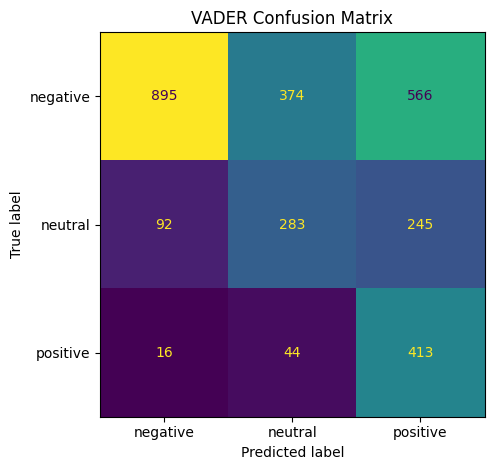

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, vader_preds, display_labels=['negative', 'neutral', 'positive'], colorbar=False)
plt.title('VADER Confusion Matrix')
plt.tight_layout()
plt.show()

### Machine Learning: Logistic Regression & Naive Bayes

Traditional ML models take our TF-IDF vectors as input and learn weights to separate the three sentiment classes. We'll compare two common choices:

- **Logistic Regression** fits a linear decision boundary; tends to work well on high-dimensional sparse text features
- **Multinomial Naive Bayes** assumes word counts are independent given the class; fast and surprisingly effective on text

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_tfidf_bal, y_train_bal)
lr_preds = lr.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf_bal, y_train_bal)
nb_preds = nb.predict(X_test_tfidf)

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_preds))

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.89      0.80      0.84      1835
     neutral       0.55      0.67      0.60       620
    positive       0.62      0.68      0.65       473

    accuracy                           0.75      2928
   macro avg       0.69      0.72      0.70      2928
weighted avg       0.77      0.75      0.76      2928

=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.86      0.78      0.82      1835
     neutral       0.51      0.59      0.55       620
    positive       0.59      0.69      0.64       473

    accuracy                           0.73      2928
   macro avg       0.65      0.69      0.67      2928
weighted avg       0.74      0.73      0.73      2928



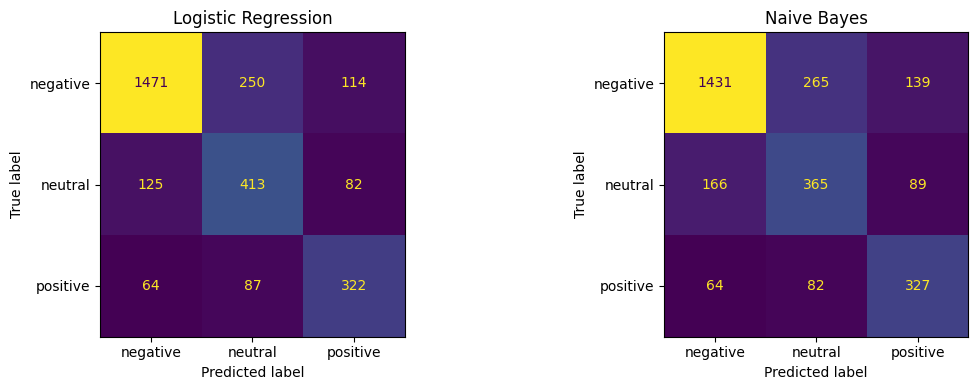

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, display_labels=['negative', 'neutral', 'positive'], colorbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, nb_preds, display_labels=['negative', 'neutral', 'positive'], colorbar=False, ax=axes[1])
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

### Neural Network: Multilayer Perceptron

A **Multilayer Perceptron (MLP)** is a fully connected neural network. Unlike Logistic Regression, it can learn non-linear relationships between features. We feed it our averaged Word2Vec document vectors, which are dense and lower-dimensional, a better fit for neural networks than sparse TF-IDF matrices.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Two hidden layers
    activation='relu',
    max_iter=50,
    random_state=RANDOM_STATE,
    verbose=False
)
mlp.fit(X_train_w2v_bal, y_train_bal)
mlp_preds = mlp.predict(X_test_w2v)

print("=== MLP (Word2Vec features) ===")
print(classification_report(y_test, mlp_preds))

=== MLP (Word2Vec features) ===
              precision    recall  f1-score   support

    negative       0.88      0.58      0.70      1835
     neutral       0.41      0.63      0.50       620
    positive       0.44      0.71      0.54       473

    accuracy                           0.61      2928
   macro avg       0.58      0.64      0.58      2928
weighted avg       0.71      0.61      0.63      2928



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


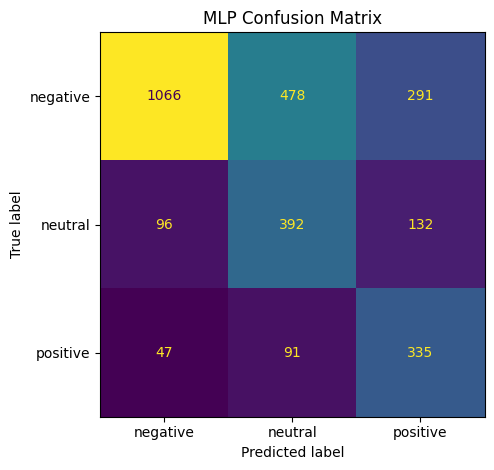

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, mlp_preds, display_labels=['negative', 'neutral', 'positive'], colorbar=False)
plt.title('MLP Confusion Matrix')
plt.tight_layout()
plt.show()

### Hybrid: VADER + TF-IDF + Logistic Regression

A **hybrid** approach combines features from multiple sources. Here, we combine the VADER compound score with our TF-IDF vectors, then train a Logistic Regression on top. This lets the model leverage both hard-coded sentiment knowledge and learned word statistics simultaneously.

In [ ]:
from scipy.sparse import hstack, csr_matrix

# Get VADER compound scores for every tweet
vader_scores = df['text'].apply(lambda t: sia.polarity_scores(t)['compound']).values.reshape(-1, 1)
vader_sparse = csr_matrix(vader_scores)

# Concatenate VADER score with TF-IDF matrix
X_hybrid = hstack([X_tfidf, vader_sparse])

X_train_hybrid, X_test_hybrid, _, _ = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_hybrid_bal, y_train_bal = smote.fit_resample(X_train_hybrid, y_train)

lr_hybrid = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_hybrid.fit(X_train_hybrid_bal, y_train_bal)
hybrid_preds = lr_hybrid.predict(X_test_hybrid)

print("=== Hybrid (VADER + TF-IDF + Logistic Regression) ===")
print(classification_report(y_test, hybrid_preds))

=== Hybrid (VADER + TF-IDF + Logistic Regression) ===
              precision    recall  f1-score   support

    negative       0.89      0.80      0.84      1835
     neutral       0.56      0.68      0.61       620
    positive       0.65      0.71      0.68       473

    accuracy                           0.76      2928
   macro avg       0.70      0.73      0.71      2928
weighted avg       0.78      0.76      0.77      2928



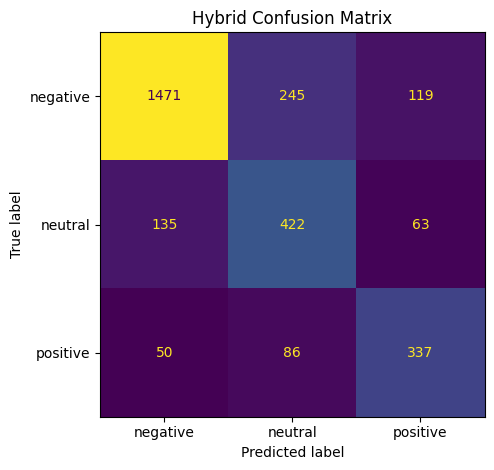

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, hybrid_preds, display_labels=['negative', 'neutral', 'positive'], colorbar=False)
plt.title('Hybrid Confusion Matrix')
plt.tight_layout()
plt.show()

### Model Comparison

Let's summarize the weighted F1 score of each approach side by side.

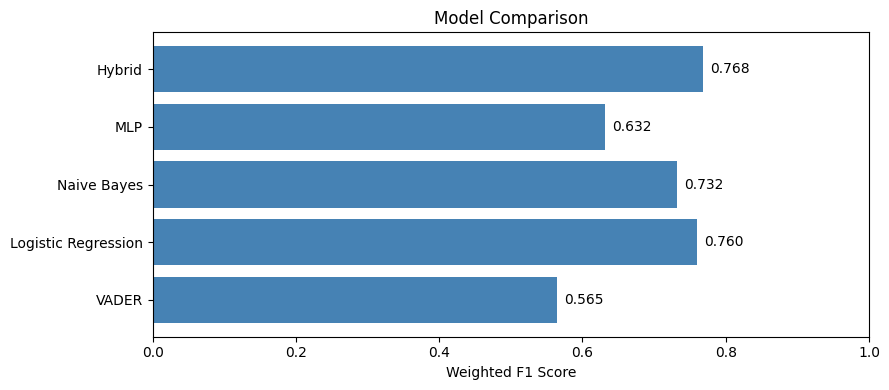

In [ ]:
from sklearn.metrics import f1_score

models = ['VADER', 'Logistic Regression', 'Naive Bayes', 'MLP', 'Hybrid']
preds  = [vader_preds, lr_preds, nb_preds, mlp_preds, hybrid_preds]
scores = [f1_score(y_test, p, average='weighted') for p in preds]

plt.figure(figsize=(9, 4))
bars = plt.barh(models, scores, color='steelblue')
plt.xlim(0, 1)
plt.xlabel('Weighted F1 Score')
plt.title('Model Comparison')
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{score:.3f}', va='center')
plt.tight_layout()
plt.show()

### Let's Try It!

In [ ]:
# Try the each model on your own text
example = "@United I can't believe my flight was cancelled again with no explanation. Terrible service." # NDL's example
your_sample = "" # Replace with your own tweet

processed_example = preprocess(example)
processed_your_sample = preprocess(your_sample)

vader_score_example = sia.polarity_scores(example)['compound']
vader_score_your_sample = sia.polarity_scores(your_sample)['compound']

example_tfidf = tfidf_vectorizer.transform([processed_example])
example_w2v   = get_doc_embedding(processed_example.split(), w2v_model).reshape(1, -1)
example_hybrid = hstack([example_tfidf, csr_matrix([[vader_score_example]] )])

your_sample_tfidf = tfidf_vectorizer.transform([processed_your_sample])
your_sample_w2v   = get_doc_embedding(processed_your_sample.split(), w2v_model).reshape(1, -1)
your_sample_hybrid = hstack([your_sample_tfidf, csr_matrix([[vader_score_your_sample]] )])

print(f"NDL's Input: '{example}'")
print()
print(f"NDL's VADER:               {vader_predict(example)}")
print(f"NDL's Logistic Regression: {lr.predict(example_tfidf)[0]}")
print(f"NDL's Naive Bayes:         {nb.predict(example_tfidf)[0]}")
print(f"NDL's MLP:                 {mlp.predict(example_w2v)[0]}")
print(f"NDL's Hybrid:              {lr_hybrid.predict(example_hybrid)[0]}")
print()
print(f"Your Input: '{your_sample}'")
print()
print(f"Your VADER:               {vader_predict(your_sample)}")
print(f"Your Logistic Regression: {lr.predict(your_sample_tfidf)[0]}")
print(f"Your Naive Bayes:         {nb.predict(your_sample_tfidf)[0]}")
print(f"Your MLP:                 {mlp.predict(your_sample_w2v)[0]}")
print(f"Your Hybrid:              {lr_hybrid.predict(your_sample_hybrid)[0]}")

NDL's Input: '@United I can't believe my flight was cancelled again with no explanation. Terrible service.'

NDL's VADER:               negative
NDL's Logistic Regression: negative
NDL's Naive Bayes:         negative
NDL's MLP:                 negative
NDL's Hybrid:              negative

Your Input: ''

Your VADER:               neutral
Your Logistic Regression: neutral
Your Naive Bayes:         negative
Your MLP:                 neutral
Your Hybrid:              neutral


## Airline Sentiment Report

Now that we have a trained model, we can apply it to the full dataset and break down predicted sentiment by airline, turning our classifier into a practical analysis tool.

In [ ]:
df['predicted_sentiment'] = lr.predict(X_tfidf)

airline_sentiment = df.groupby(['airline', 'predicted_sentiment']).size().unstack(fill_value=0)
airline_sentiment_pct = airline_sentiment.div(airline_sentiment.sum(axis=1), axis=0) * 100

print(airline_sentiment_pct.round(1))

predicted_sentiment  negative  neutral  positive
airline                                         
American                 65.0     20.9      14.1
Delta                    39.3     34.9      25.7
Southwest                45.1     29.6      25.3
US Airways               72.5     15.8      11.7
United                   62.7     21.8      15.5
Virgin America           35.3     34.3      30.4


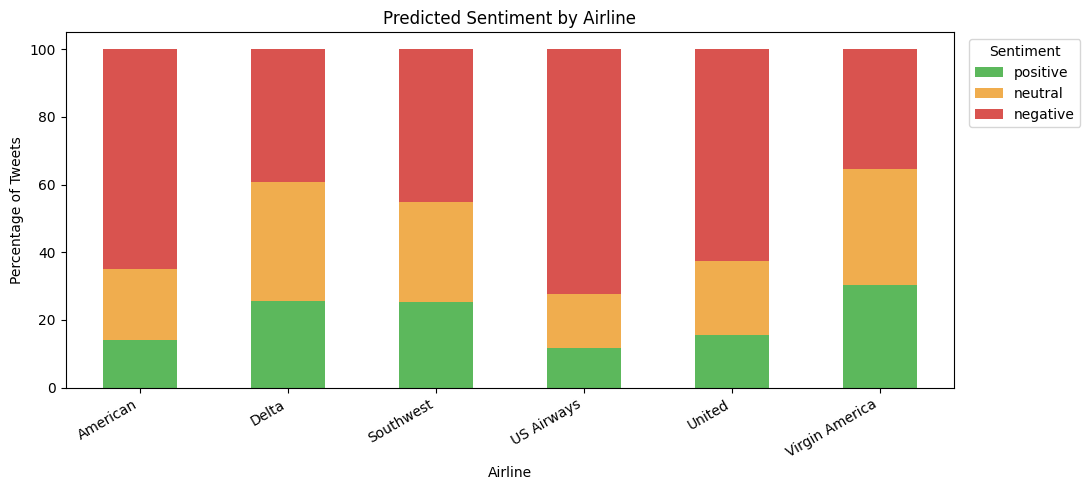

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

airline_sentiment_pct[['positive', 'neutral', 'negative']].plot(
    kind='bar',
    stacked=True,
    color=['#5cb85c', '#f0ad4e', '#d9534f'],
    ax=ax
)

ax.set_title('Predicted Sentiment by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Percentage of Tweets')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

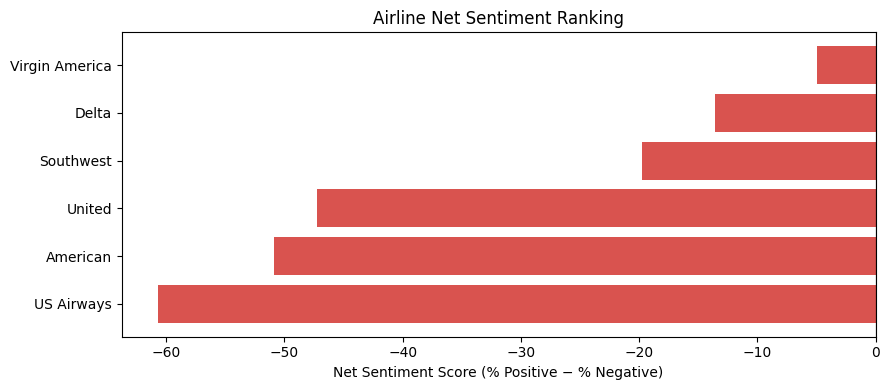

In [ ]:
# Net sentiment score: % positive minus % negative
airline_sentiment_pct['net_score'] = (
    airline_sentiment_pct['positive'] - airline_sentiment_pct['negative']
)

ranking = airline_sentiment_pct['net_score'].sort_values(ascending=False)

plt.figure(figsize=(9, 4))
colors = ['#5cb85c' if s >= 0 else '#d9534f' for s in ranking.values]
bars = plt.barh(ranking.index[::-1], ranking.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Net Sentiment Score (% Positive − % Negative)')
plt.title('Airline Net Sentiment Ranking')
plt.tight_layout()
plt.show()

## Extension Activities

The dataset contains several columns we haven't touched that open up interesting follow-up questions:

**`negativereason`**: negative tweets are labeled with a specific reason (e.g. *Late Flight*, *Lost Luggage*, *Customer Service Issue*). You could train a secondary classifier that predicts the reason given that a tweet is already known to be negative: a form of aspect-based sentiment analysis.

**`airline_sentiment_confidence`**: each label comes with a confidence score from the human annotators. Try filtering to only high-confidence examples (e.g. `>= 0.9`) and see how model performance changes. Do models learn better from cleaner labels?

**`retweet_count`**: does sentiment correlate with virality? A highly negative tweet might get retweeted more. Try a simple correlation analysis or group tweets by sentiment and compare average retweet counts.

**`tweet_created`**: the timestamps let you look at sentiment over time. Did a particular airline have a bad week? You could resample by day and plot a sentiment trend line using the net score approach from the report section above. This is a natural extension of the [time series](https://github.com/psundl/nittany-data-labs/blob/main/spring-2026-meetings/2026-2-8-time-series-analysis/Time_Series_Analysis_Lab.ipynb) and [ARIMA modeling](https://github.com/psundl/nittany-data-labs/blob/main/spring-2026-meetings/2026-2-15-arima/ARIMA_Modeling_Lab_Main.ipynb) techniques we covered in our last two labs.

**`tweet_location`**: a subset of tweets have location data. Is sentiment geographically distributed? Certain hub cities might show stronger negative sentiment toward specific airlines.